# Hubbard time evolution to Clifford + T: fixed-time scaling study

**The model.** Fermions with two spin species $\sigma\in\{\uparrow,\downarrow\}$
hop along a 1D chain of $L$ sites with rate $J$; two fermions of *opposite* spin
on the same site pay an interaction energy $U$:

$$H \;=\; -J\sum_{\langle i,j\rangle,\sigma}
      \big(c^\dagger_{i\sigma} c_{j\sigma} + \text{h.c.}\big)
      \;+\; U \sum_{i} n_{i\uparrow}\, n_{i\downarrow}.$$

**The pipeline** (every stage is a plain function, so the whole thing is sweepable):

1. **Jordan–Wigner** the fermions onto $2L$ qubits — the antisymmetric statistics
   become explicit **Z-strings** on the Pauli terms (validated against an
   independent Fock-space construction of $H$);
2. **Trotter–Suzuki** product formula with an adjustable **time step `dt`**,
   **number of steps `n_steps`**, and **order** (1, 2, 4, 6, … via the Suzuki
   fractal recursion) — the output is an ordered list of **multi-qubit Pauli
   rotations** $e^{-i\theta_k P_k/2}$, shrunk for free by two exact identities
   (adjacent merge + global **commuting fusion**, on by default — §6.1 audits it
   against the ZX-calculus);



The study has four non-negotiable invariants:

- one-dimensional Hubbard chain with **open boundary conditions**;
- `J = 1` and `U = 1` everywhere;
- every point evolves to the same final time `T_FINAL = 3/J`;
- `dt` is derived as `T_FINAL / n_steps` (never specified independently).

The main output is T-count versus number of sites for orders 1, 2, and 4 and
several step counts.  Two resource models are shown:

1. deterministic, ancilla-free Ross-Selinger synthesis of every remaining rotation;
2. an ancilla-assisted Hamming-weight-phasing (HWP) estimate for consecutive batches
   of equal-angle, commuting rotations.

Both models use the **same circuit-level synthesis-error budget**, so system sizes
and product formulas are compared on equal footing.


In [1]:
from collections import Counter
from functools import lru_cache
from importlib.metadata import version

import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np
from scipy.linalg import expm

import pygridsynth

mp.mp.dps = 60
np.set_printoptions(linewidth=120, precision=4, suppress=True)

# Physics and boundary conditions are deliberately constants, not sweep parameters.
J = 1.0
U = 1.0
PERIODIC = False

# Every schedule below reaches this same time.
T_FINAL = 3.0 / J  # dimensionless evolution time J*t = 3
TROTTER_ORDERS = (1, 2, 4)
N_STEPS_GRID = (1, 2, 4, 8)
SYSTEM_SIZES = (2, 4, 8, 16, 30, 60)  # sites; number of qubits is 2L

# Conservative whole-circuit synthesis budget.  If N rotations remain, the
# ancilla-free model uses eps_per_rotation = EPS_SYNTH_TOTAL / N.
EPS_SYNTH_TOTAL = mp.mpf("1e-6")

print(
    "numpy", np.__version__,
    "| scipy", version("scipy"),
    "| pygridsynth", version("pygridsynth"),
)
print(f"fixed model: J={J}, U={U}, open boundaries={not PERIODIC}, final time={T_FINAL}")
print("step schedules:", {r: T_FINAL / r for r in N_STEPS_GRID}, "(n_steps -> dt)")


numpy 2.4.6 | scipy 1.18.0 | pygridsynth 2.0.0
fixed model: J=1.0, U=1.0, open boundaries=True, final time=3.0
step schedules: {1: 3.0, 2: 1.5, 4: 0.75, 8: 0.375} (n_steps -> dt)


## 1. Model and Jordan-Wigner map

With interleaved modes `p = 2*site + spin`, nearest-neighbour hopping maps to
weight-three Pauli strings and the on-site interaction maps to diagonal terms:

$$
H = -\frac{J}{2}\sum_{\langle i,j\rangle,\sigma}
    (X_i Z X_j + Y_i Z Y_j)
  + \frac{U}{4}\sum_i (Z_{i\uparrow}Z_{i\downarrow}
    -Z_{i\uparrow}-Z_{i\downarrow})
  + \frac{UL}{4}I.
$$

Pauli labels are little-endian: character `q` acts on qubit `q`.  The identity
term is tracked but omitted from an uncontrolled circuit because it contributes
only global phase.  It must be restored for controlled evolution or ordinary
phase estimation.


In [2]:
PAULI1 = {
    "I": np.eye(2, dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}


def pauli_matrix(label):
    """Dense little-endian Pauli matrix; validation only."""
    out = np.array([[1.0 + 0.0j]])
    for symbol in label:
        out = np.kron(PAULI1[symbol], out)
    return out


def hubbard_jw_terms(L):
    """Open 1D Hubbard Hamiltonian for the fixed J=U=1 study.

    Returns ordered (Pauli label, coefficient) terms and the omitted identity
    coefficient.  There are 4(L-1) hopping terms and 3L interaction terms.
    """
    if L < 1:
        raise ValueError("L must be positive")

    n_qubits = 2 * L
    accumulated = {}

    def add(support, coefficient):
        label = "".join(support.get(q, "I") for q in range(n_qubits))
        accumulated[label] = accumulated.get(label, 0.0) + coefficient

    # Open boundaries only: no wrap-around bond.
    for site in range(L - 1):
        for spin in (0, 1):
            p, q = 2 * site + spin, 2 * (site + 1) + spin
            z_string = {k: "Z" for k in range(p + 1, q)}
            add({p: "X", q: "X", **z_string}, -J / 2)
            add({p: "Y", q: "Y", **z_string}, -J / 2)

    identity_coefficient = 0.0
    for site in range(L):
        up, down = 2 * site, 2 * site + 1
        add({up: "Z", down: "Z"}, U / 4)
        add({up: "Z"}, -U / 4)
        add({down: "Z"}, -U / 4)
        identity_coefficient += U / 4

    terms = [(label, coeff) for label, coeff in accumulated.items() if abs(coeff) > 1e-15]
    return terms, identity_coefficient


def fock_annihilation(mode, n_modes):
    """Fermionic annihilation matrix from its occupation-basis definition."""
    dim = 1 << n_modes
    out = np.zeros((dim, dim), dtype=complex)
    lower_mask = (1 << mode) - 1
    for basis_state in range(dim):
        if (basis_state >> mode) & 1:
            parity = (basis_state & lower_mask).bit_count()
            out[basis_state ^ (1 << mode), basis_state] = (-1) ** parity
    return out


def hubbard_fock(L):
    """Independent dense Fock-space construction; validation only."""
    n_modes = 2 * L
    annihilation = [fock_annihilation(p, n_modes) for p in range(n_modes)]
    creation = [op.conj().T for op in annihilation]
    out = np.zeros((1 << n_modes, 1 << n_modes), dtype=complex)

    for site in range(L - 1):
        for spin in (0, 1):
            p, q = 2 * site + spin, 2 * (site + 1) + spin
            out += -J * (creation[p] @ annihilation[q] + creation[q] @ annihilation[p])
    for site in range(L):
        n_up = creation[2 * site] @ annihilation[2 * site]
        n_down = creation[2 * site + 1] @ annihilation[2 * site + 1]
        out += U * (n_up @ n_down)
    return out


def jw_matrix(terms, identity_coefficient=0.0):
    n_qubits = len(terms[0][0])
    out = identity_coefficient * np.eye(1 << n_qubits, dtype=complex)
    for label, coefficient in terms:
        out += coefficient * pauli_matrix(label)
    return out


terms2, e_identity2 = hubbard_jw_terms(2)
mapping_error = np.linalg.norm(jw_matrix(terms2, e_identity2) - hubbard_fock(2))
assert mapping_error < 1e-12
for L in SYSTEM_SIZES:
    terms, _ = hubbard_jw_terms(L)
    assert len(terms) == 7 * L - 4

print(f"L=2 mapping check ||H_JW-H_Fock|| = {mapping_error:.2e}")
print("term count check: 7L-4 for every plotted system size")


L=2 mapping check ||H_JW-H_Fock|| = 0.00e+00
term count check: 7L-4 for every plotted system size


## 2. Product-formula schedule and exact symbolic simplification

A rotation tuple `(P, theta)` means $\exp(-i\,\theta P/2)$.  Order 1 uses a Lie
sweep, order 2 uses a symmetric Strang sweep, and order 4 uses Suzuki's five-block
recursion.  The list convention is circuit order: the first tuple acts first.

Two exact passes run before any approximate synthesis:

- merge adjacent equal-axis rotations;
- move a rotation backwards only through rotations that commute with it, then
  fuse it with an earlier copy of the same Pauli.

This domain pass scales to large systems and preserves floating-point angles.  It
is the default scalable pass; PyZX phase teleportation is better retained as a
bounded-size audit rather than placed inside the full sweep.


In [3]:
def suzuki_scales(order):
    """Scale factors expressing an even-order step as Strang steps."""
    if order == 2:
        return (1.0,)
    if order < 2 or order % 2:
        raise ValueError("order must be 2 or a larger even integer")
    p = 1.0 / (4.0 - 4.0 ** (1.0 / (order - 1)))
    inner = suzuki_scales(order - 2)
    return tuple(
        [p * x for x in inner] * 2
        + [(1.0 - 4.0 * p) * x for x in inner]
        + [p * x for x in inner] * 2
    )


def trotter_rotations(terms, final_time, n_steps, order):
    """Rotation list for fixed final_time; dt is always derived."""
    if n_steps < 1:
        raise ValueError("n_steps must be positive")
    dt = final_time / n_steps

    if order == 1:
        one_step = [(label, 2.0 * coeff * dt) for label, coeff in terms]
    else:
        if order < 2 or order % 2:
            raise ValueError("order must be 1 or an even integer")
        one_step = []
        for scale in suzuki_scales(order):
            half_sweep = [(label, coeff * scale * dt) for label, coeff in terms]
            one_step.extend(half_sweep)
            one_step.extend(reversed(half_sweep))
    return one_step * n_steps


def merge_adjacent(rotations, atol=1e-13):
    out = []
    for label, angle in rotations:
        if abs(angle) < atol:
            continue
        if out and out[-1][0] == label:
            merged = out[-1][1] + angle
            if abs(merged) < atol:
                out.pop()
            else:
                out[-1] = (label, merged)
        else:
            out.append((label, angle))
    return out


@lru_cache(maxsize=None)
def pauli_masks(label):
    """Binary symplectic (x,z) masks for a Pauli label."""
    x_mask = 0
    z_mask = 0
    for q, symbol in enumerate(label):
        if symbol in "XY":
            x_mask |= 1 << q
        if symbol in "YZ":
            z_mask |= 1 << q
    return x_mask, z_mask


@lru_cache(maxsize=None)
def paulis_commute(label_a, label_b):
    xa, za = pauli_masks(label_a)
    xb, zb = pauli_masks(label_b)
    return (((xa & zb) ^ (za & xb)).bit_count() % 2) == 0


def fuse_commuting(rotations, atol=1e-13):
    """Fuse equal Paulis through a suffix that commutes with that Pauli."""
    out = []
    for label, angle in rotations:
        target = None
        for pos in range(len(out) - 1, -1, -1):
            earlier_label = out[pos][0]
            if earlier_label == label:
                target = pos
                break
            if not paulis_commute(earlier_label, label):
                break

        if target is None:
            if abs(angle) >= atol:
                out.append([label, angle])
        else:
            out[target][1] += angle
            if abs(out[target][1]) < atol:
                out.pop(target)
    return [(label, angle) for label, angle in out]


def optimized_rotations(L, n_steps, order, final_time=T_FINAL):
    terms, _ = hubbard_jw_terms(L)
    raw = trotter_rotations(terms, final_time, n_steps, order)
    return raw, fuse_commuting(merge_adjacent(raw))


for order in TROTTER_ORDERS:
    raw, optimized = optimized_rotations(L=4, n_steps=4, order=order)
    print(f"order {order}: {len(raw):5d} raw rotations -> {len(optimized):5d} after exact folding")


order 1:    96 raw rotations ->    96 after exact folding
order 2:   192 raw rotations ->   132 after exact folding
order 4:   960 raw rotations ->   644 after exact folding


### 2.1 Small-system convergence and rewrite checks

Dense matrices are used only here.  The dropped identity term is also removed from
the exact reference, so the comparison contains no ambiguous global phase.


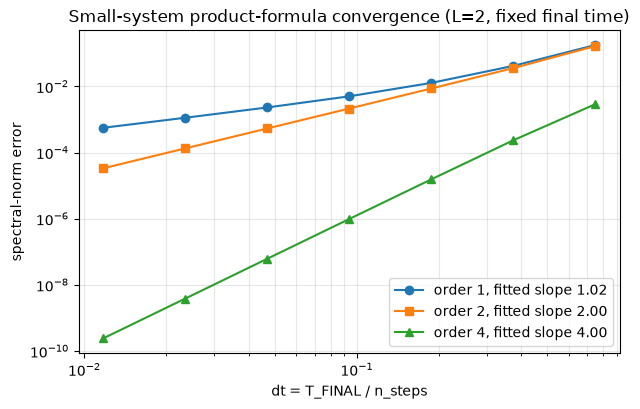

exact rewrite check ||U_raw-U_folded|| = 2.69e-15


In [4]:
def dense_rotation_product(rotations):
    n_qubits = len(rotations[0][0])
    identity = np.eye(1 << n_qubits, dtype=complex)
    paulis = {label: pauli_matrix(label) for label, _ in rotations}
    out = identity.copy()
    for label, angle in rotations:
        # P^2=I, so this is much cheaper and cleaner than expm for every factor.
        gate = np.cos(angle / 2) * identity - 1j * np.sin(angle / 2) * paulis[label]
        out = gate @ out
    return out


terms2, _ = hubbard_jw_terms(2)
exact_no_identity = expm(-1j * jw_matrix(terms2, 0.0) * T_FINAL)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
verification_steps = (4, 8, 16, 32, 64, 128, 256)
for order, marker in zip(TROTTER_ORDERS, ("o", "s", "^")):
    errors = []
    dts = []
    for n_steps in verification_steps:
        raw = trotter_rotations(terms2, T_FINAL, n_steps, order)
        optimized = fuse_commuting(merge_adjacent(raw))
        error = np.linalg.norm(dense_rotation_product(optimized) - exact_no_identity, ord=2)
        errors.append(float(error))
        dts.append(T_FINAL / n_steps)
    slope = np.polyfit(np.log(dts[-3:]), np.log(errors[-3:]), 1)[0]
    ax.loglog(dts, errors, marker + "-", label=f"order {order}, fitted slope {slope:.2f}")

raw_check = trotter_rotations(terms2, T_FINAL, n_steps=3, order=2)
fused_check = fuse_commuting(merge_adjacent(raw_check))
rewrite_error = np.linalg.norm(
    dense_rotation_product(raw_check) - dense_rotation_product(fused_check), ord=2
)
assert rewrite_error < 1e-11

ax.set_xlabel("dt = T_FINAL / n_steps")
ax.set_ylabel("spectral-norm error")
ax.set_title("Small-system product-formula convergence (L=2, fixed final time)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"exact rewrite check ||U_raw-U_folded|| = {rewrite_error:.2e}")


## 3. Clifford + T cost models

Each Pauli rotation uses a Clifford basis change, a parity network, one `Rz`, and
the inverse Clifford scaffold.  A weight-$w$ Pauli costs $2(w-1)$ CNOTs in the
simple ladder construction, but still only one arbitrary rotation.

### Model A: deterministic and ancilla-free

`pygridsynth` implements Ross-Selinger number-theoretic synthesis.  It is a strong,
reproducible deterministic baseline, not a claim that independent synthesis is the
best architecture-level strategy.  If `N_R` rotations survive, each receives

$$\epsilon_j = \epsilon_{\rm synth,total}/N_R.$$

The telescoping bound then guarantees total synthesis error no larger than the
declared circuit budget.  This changes the asymptotic picture from artificially
linear scaling (fixed error *per rotation*) to roughly $N_R\log N_R$ at fixed total
error.

### Model B: Hamming-weight phasing

Consecutive, equal-angle, pairwise-commuting rotations are grouped.  A batch of
size $m$ is represented by `floor(log2(m))+1` synthesized rotations on a coherent
Hamming-weight register plus `m-popcount(m)` Toffolis.  We charge 4 T gates per
temporary-AND Toffoli and zero-T measurement-based uncomputation.  For general
Pauli axes, a direct implementation can additionally use up to one parity ancilla
per member of the largest batch.  This is an explicit T-count/ancilla trade, not a
free optimization.


In [5]:
ANGLE_DIGITS = 13  # far below the smallest per-rotation tolerance in this sweep


def canonical_angle(angle):
    """Angle in [0, 2pi), rounded only for multiplicity detection."""
    reduced = float(angle) % (2.0 * np.pi)
    if np.isclose(reduced, 2.0 * np.pi, atol=1e-13, rtol=0.0):
        reduced = 0.0
    return round(reduced, ANGLE_DIGITS)


def is_clifford_angle(angle, atol=1e-12):
    multiple = round(float(angle) / (np.pi / 2.0))
    return abs(float(angle) - multiple * (np.pi / 2.0)) < atol


SYNTHESIS_CACHE = {}


def gridsynth_t_count(angle, epsilon):
    """T-count of an ancilla-free approximation to Rz(angle)."""
    angle = canonical_angle(angle)
    if is_clifford_angle(angle):
        return 0
    eps = mp.mpf(epsilon)
    key = (angle, mp.nstr(eps, 50))
    if key not in SYNTHESIS_CACHE:
        word = pygridsynth.gridsynth_gates(mp.mpf(repr(angle)), eps)
        SYNTHESIS_CACHE[key] = word.count("T")
    return SYNTHESIS_CACHE[key]


def nonclifford_angle_counter(rotations):
    return Counter(
        canonical_angle(angle)
        for _, angle in rotations
        if not is_clifford_angle(canonical_angle(angle))
    )


def price_angle_counter(angle_counter, epsilon_total):
    """Price repeated Rz angles under one additive circuit-level error budget."""
    n_rotations = sum(angle_counter.values())
    if n_rotations == 0:
        return {"n_synth_rotations": 0, "eps_each": mp.inf, "t_synthesis": 0}
    eps_each = mp.mpf(epsilon_total) / n_rotations
    t_synthesis = sum(
        multiplicity * gridsynth_t_count(angle, eps_each)
        for angle, multiplicity in angle_counter.items()
    )
    return {
        "n_synth_rotations": n_rotations,
        "eps_each": eps_each,
        "t_synthesis": int(t_synthesis),
    }


def consecutive_commuting_batches(rotations):
    """Valid HWP batches without changing circuit order.

    Clifford-angle rotations end a batch.  A non-Clifford rotation joins the
    current batch only if its angle matches and its Pauli commutes with every
    member already in that consecutive batch.
    """
    batches = []
    labels = []
    batch_angle = None

    def flush():
        nonlocal labels, batch_angle
        if labels:
            batches.append((batch_angle, tuple(labels)))
        labels = []
        batch_angle = None

    for label, angle in rotations:
        reduced = canonical_angle(angle)
        if is_clifford_angle(reduced):
            flush()
            continue
        fits = (
            labels
            and reduced == batch_angle
            and all(paulis_commute(label, other) for other in labels)
        )
        if not labels:
            batch_angle = reduced
            labels = [label]
        elif fits:
            labels.append(label)
        else:
            flush()
            batch_angle = reduced
            labels = [label]
    flush()
    return batches


def hwp_resources(rotations, epsilon_total):
    """Conservative consecutive-batch HWP T-count estimate."""
    derived_angles = Counter()
    n_toffoli = 0
    max_batch = 0
    max_hwp_work_ancillas = 0

    for angle, labels in consecutive_commuting_batches(rotations):
        batch_size = len(labels)
        max_batch = max(max_batch, batch_size)
        n_weight_bits = batch_size.bit_length()
        n_toffoli += batch_size - batch_size.bit_count()
        max_hwp_work_ancillas = max(
            max_hwp_work_ancillas,
            batch_size - batch_size.bit_count() + n_weight_bits,
        )
        for bit in range(n_weight_bits):
            derived = canonical_angle((2**bit) * angle)
            if not is_clifford_angle(derived):
                derived_angles[derived] += 1

    priced = price_angle_counter(derived_angles, epsilon_total)
    return {
        **priced,
        "n_toffoli": n_toffoli,
        "t_toffoli": 4 * n_toffoli,
        "t_count": priced["t_synthesis"] + 4 * n_toffoli,
        "max_batch": max_batch,
        "max_hwp_work_ancillas": max_hwp_work_ancillas,
    }


def compile_resources(L, n_steps, order, final_time=T_FINAL, epsilon_total=EPS_SYNTH_TOTAL):
    """Symbolic Hubbard compilation and two Clifford+T resource estimates."""
    terms, identity_coefficient = hubbard_jw_terms(L)
    raw = trotter_rotations(terms, final_time, n_steps, order)
    rotations = fuse_commuting(merge_adjacent(raw))

    angle_counter = nonclifford_angle_counter(rotations)
    serial = price_angle_counter(angle_counter, epsilon_total)
    hwp = hwp_resources(rotations, epsilon_total)
    cnot_ladder = sum(
        2 * (sum(symbol != "I" for symbol in label) - 1)
        for label, _ in rotations
    )

    return {
        "L": L,
        "n_qubits": 2 * L,
        "J": J,
        "U": U,
        "periodic": PERIODIC,
        "final_time": final_time,
        "n_steps": n_steps,
        "dt": final_time / n_steps,
        "order": order,
        "epsilon_total": float(epsilon_total),
        "identity_coefficient": identity_coefficient,
        "n_terms": len(terms),
        "n_rotations_raw": len(raw),
        "n_rotations_folded": len(rotations),
        "n_rz": serial["n_synth_rotations"],
        "eps_per_rz": float(serial["eps_each"]),
        "t_count_serial": serial["t_synthesis"],
        "t_count_hwp": hwp["t_count"],
        "hwp_synth_rotations": hwp["n_synth_rotations"],
        "hwp_toffoli": hwp["n_toffoli"],
        "hwp_max_batch": hwp["max_batch"],
        "hwp_work_ancillas": hwp["max_hwp_work_ancillas"],
        "hwp_parity_ancillas_upper": hwp["max_batch"],
        "cnot_ladder": cnot_ladder,
    }


demo = compile_resources(L=8, n_steps=4, order=2)
for key in (
    "n_terms", "n_rotations_raw", "n_rotations_folded", "n_rz",
    "eps_per_rz", "t_count_serial", "t_count_hwp", "hwp_max_batch",
    "hwp_work_ancillas", "hwp_parity_ancillas_upper", "cnot_ladder",
):
    print(f"{key:>24}: {demo[key]}")


                 n_terms: 52
         n_rotations_raw: 416
      n_rotations_folded: 308
                    n_rz: 308
              eps_per_rz: 3.2467532467532466e-09
          t_count_serial: 27128
             t_count_hwp: 23368
           hwp_max_batch: 4
       hwp_work_ancillas: 6
hwp_parity_ancillas_upper: 4
             cnot_ladder: 912


## 4. Fixed-time scaling sweep

The sweep keys schedules by integer `n_steps`; `dt` is calculated from the common
final time.  Therefore every line in every panel represents the same physical
evolution duration.  The symbolic compiler never builds a state vector or a full
gate list, so 120-qubit (`L=60`) points remain inexpensive.


In [6]:
records = []
for order in TROTTER_ORDERS:
    for n_steps in N_STEPS_GRID:
        for L in SYSTEM_SIZES:
            records.append(compile_resources(L=L, n_steps=n_steps, order=order))


def select(order, n_steps, field):
    rows = [r for r in records if r["order"] == order and r["n_steps"] == n_steps]
    rows.sort(key=lambda row: row["L"])
    return [row[field] for row in rows]


print(
    f"{'L':>3} {'ord':>3} {'steps':>5} {'dt':>7} {'Rz':>8} "
    f"{'T serial':>10} {'T HWP':>10} {'saving':>8}"
)
for row in records:
    if row["L"] in (2, 60):
        saving = 1.0 - row["t_count_hwp"] / row["t_count_serial"]
        print(
            f"{row['L']:3d} {row['order']:3d} {row['n_steps']:5d} {row['dt']:7.3f} "
            f"{row['n_rz']:8d} {row['t_count_serial']:10d} {row['t_count_hwp']:10d} "
            f"{saving:7.1%}"
        )


  L ord steps      dt       Rz   T serial      T HWP   saving
  2   1     1   3.000       10        708        662    6.5%
 60   1     1   3.000      416      37080      32364   12.7%
  2   1     2   1.500       20       1480       1388    6.2%
 60   1     2   1.500      832      75600      67344   10.9%
  2   1     4   0.750       40       3040       2824    7.1%
 60   1     4   0.750     1664     161184     140880   12.6%
  2   1     8   0.375       80       6560       6080    7.3%
 60   1     8   0.375     3328     335680     293184   12.7%
  2   2     1   3.000       14       1036        888   14.3%
 60   2     1   3.000      652      57376      49832   13.1%
  2   2     2   1.500       24       1776       1622    8.7%
 60   2     2   1.500     1300     124792     101994   18.3%
  2   2     4   0.750       44       3392       3058    9.8%
 60   2     4   0.750     2596     254408     214554   15.7%
  2   2     8   0.375       84       6888       6336    8.0%
 60   2     8   0.375  

### 4.1 Main result: deterministic ancilla-free T-count

These are actual `pygridsynth` word counts under a fixed **whole-circuit** synthesis
budget.  Each panel is a Trotter order; each curve is a step schedule with
`dt = T_FINAL/n_steps`.


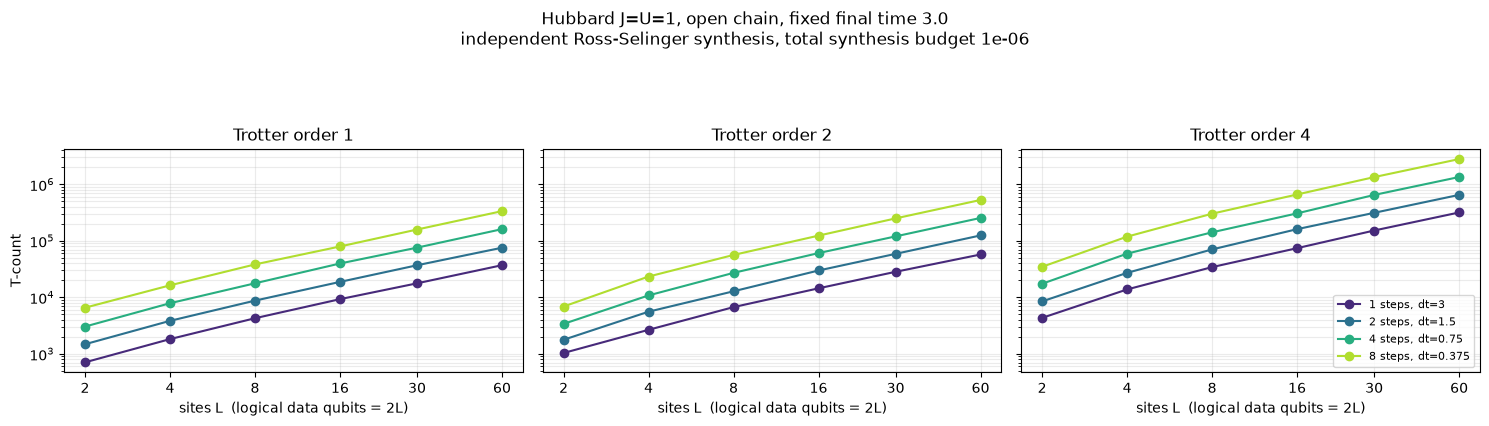

In [7]:
colors = dict(zip(N_STEPS_GRID, plt.cm.viridis(np.linspace(0.12, 0.88, len(N_STEPS_GRID)))))
fig, axes = plt.subplots(1, len(TROTTER_ORDERS), figsize=(15.0, 4.3), sharey=True)

for ax, order in zip(axes, TROTTER_ORDERS):
    for n_steps in N_STEPS_GRID:
        ax.plot(
            SYSTEM_SIZES,
            select(order, n_steps, "t_count_serial"),
            marker="o",
            color=colors[n_steps],
            label=f"{n_steps} steps, dt={T_FINAL/n_steps:g}",
        )
    ax.set_yscale("log")
    ax.set_xscale("log", base=2)
    ax.set_xticks(SYSTEM_SIZES, labels=[str(L) for L in SYSTEM_SIZES])
    ax.set_xlabel("sites L  (logical data qubits = 2L)")
    ax.set_title(f"Trotter order {order}")
    ax.grid(True, which="both", alpha=0.25)

axes[0].set_ylabel("T-count")
axes[-1].legend(fontsize=8, loc="best")
fig.suptitle(
    f"Hubbard J=U=1, open chain, fixed final time {T_FINAL}\n"
    f"independent Ross-Selinger synthesis, total synthesis budget {float(EPS_SYNTH_TOTAL):.0e}",
    y=0.98,
)
fig.tight_layout(rect=(0, 0, 1, 0.87))
plt.show()


### 4.2 Ancilla-assisted alternative: Hamming-weight phasing

This uses only consecutive equal-angle commuting batches, so it is deliberately
conservative about reordering.  It includes the 4-T temporary-AND cost of each
Toffoli.  It does **not** include the eventual surface-code spacetime cost of the
extra logical ancillas beyond the reported HWP/parity-work upper bounds, routing,
or magic-state bandwidth; those require a layout model, not just a gate count.


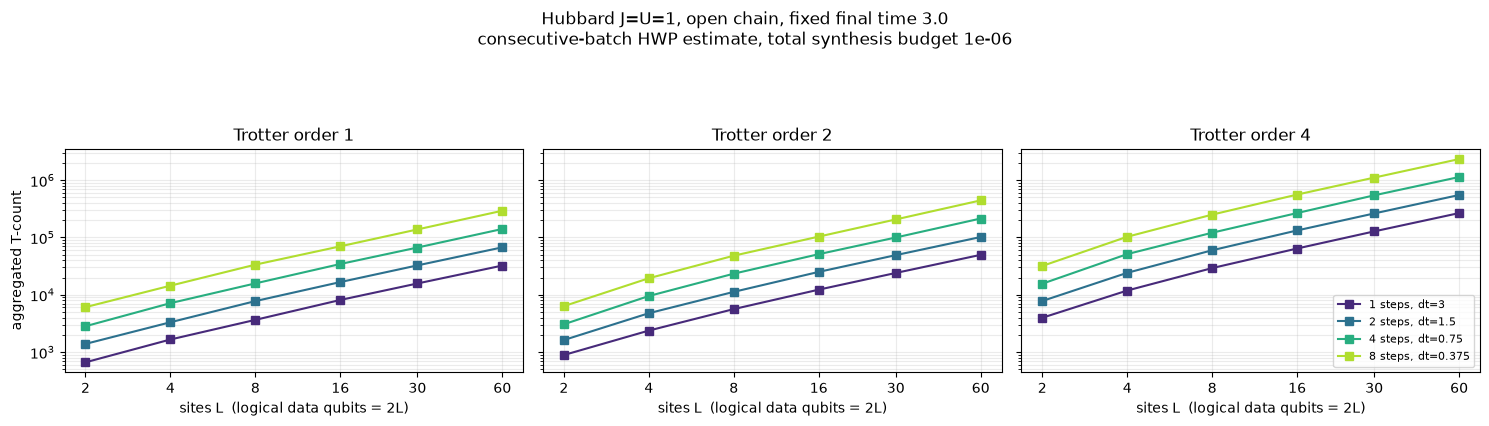

In [8]:
fig, axes = plt.subplots(1, len(TROTTER_ORDERS), figsize=(15.0, 4.3), sharey=True)

for ax, order in zip(axes, TROTTER_ORDERS):
    for n_steps in N_STEPS_GRID:
        ax.plot(
            SYSTEM_SIZES,
            select(order, n_steps, "t_count_hwp"),
            marker="s",
            color=colors[n_steps],
            label=f"{n_steps} steps, dt={T_FINAL/n_steps:g}",
        )
    ax.set_yscale("log")
    ax.set_xscale("log", base=2)
    ax.set_xticks(SYSTEM_SIZES, labels=[str(L) for L in SYSTEM_SIZES])
    ax.set_xlabel("sites L  (logical data qubits = 2L)")
    ax.set_title(f"Trotter order {order}")
    ax.grid(True, which="both", alpha=0.25)

axes[0].set_ylabel("aggregated T-count")
axes[-1].legend(fontsize=8, loc="best")
fig.suptitle(
    f"Hubbard J=U=1, open chain, fixed final time {T_FINAL}\n"
    f"consecutive-batch HWP estimate, total synthesis budget {float(EPS_SYNTH_TOTAL):.0e}",
    y=0.98,
)
fig.tight_layout(rect=(0, 0, 1, 0.87))
plt.show()


## 5. How to read the plots

- More steps always create more rotation opportunities, although exact folding can
  remove a significant fraction at symmetric seams.
- Higher Suzuki order is not automatically cheaper: order 4 uses five Strang blocks
  per step and wins only when its smaller Trotter error permits sufficiently fewer
  steps for a target accuracy.
- These plots compare **fixed schedules**, not equal achieved Trotter error.  At
  fixed `dt`, Hamiltonian-simulation error generally grows with system size because
  the Hamiltonian is extensive.  The next decision study should choose the cheapest
  `(order, n_steps)` that meets an error target at each `L`.
- The ancilla-free curves are mildly superlinear because the same total synthesis
  budget is divided among more rotations.  Linear-looking curves obtained with a
  fixed per-rotation tolerance do not provide a fair cross-size comparison.
- HWP exchanges synthesized rotations for Toffolis and logical workspace.  Lower
  T-count does not by itself imply lower lattice-surgery spacetime volume.


## 6. Recommended compiler rework

The scalable pipeline should be organized in this order:

1. **Physics IR:** emit the Hubbard Hamiltonian with an explicit mode ordering,
   boundary condition, and identity coefficient.  Validate this stage once at small
   `L` against a Fock-space construction.
2. **Structured product formula:** retain commuting layers rather than immediately
   flattening into individual Pauli rotations.  For this chain, split hopping into
   even/odd bonds and keep the entire diagonal interaction block together.  Benchmark
   layer orderings because they change the error constant.
3. **Fixed-time schedule:** expose `(T_FINAL, n_steps, order)` and derive `dt`.
   Never sweep `dt` and `n_steps` independently.
4. **Exact symbolic optimization:** merge equal Pauli gadgets through commuting
   regions before approximating any angle.  Use PyZX `teleport_reduce` on small and
   medium instances as an independent audit, not as the only scalable pass.
5. **Global error ledger:** split a declared algorithm budget into product-formula,
   rotation-synthesis, and (later) logical-failure budgets.  Allocate synthesis error
   at circuit level; equal allocation is the correct baseline when every rotation has
   the same error weight.
6. **Strategy-specific pricing:** compare independent synthesis, HWP, catalyst/phase-
   gradient methods, and their ancilla requirements without rebuilding the physics
   circuit for every cost model.
7. **Lattice-surgery backend:** add T-depth, peak simultaneous T demand, logical
   ancillas, factory throughput, code distance, and spacetime volume.  T-count alone
   is insufficient once batching is introduced.

Useful primary implementations and references:

- [PyZX optimization and phase teleportation](https://pyzx.readthedocs.io/en/stable/simplify.html)
- [Qualtran: Trotterized Hubbard building blocks](https://qualtran.readthedocs.io/en/latest/bloqs/chemistry/trotter/hubbard/hubbard.html)
- [Qualtran: Hamming-weight phasing](https://qualtran.readthedocs.io/en/latest/bloqs/rotations/hamming_weight_phasing.html)
- [Kivlichan et al., improved fault-tolerant Trotter simulation](https://quantum-journal.org/papers/q-2020-07-16-296/)
- [Bothe et al., small-angle Clifford+T synthesis for Trotterization](https://arxiv.org/abs/2605.31544)


### References

1. P. Jordan and E. Wigner, “Über das Paulische Äquivalenzverbot,” *Z. Phys.*
   **47**, 631–651 (1928), [doi:10.1007/BF01331938](https://doi.org/10.1007/BF01331938).
2. M. Suzuki, “Fractal decomposition of exponential operators with applications
   to many-body theories and Monte Carlo simulations,” *Phys. Lett. A* **146**,
   319–323 (1990),
   [doi:10.1016/0375-9601(90)90962-N](https://doi.org/10.1016/0375-9601(90)90962-N).
3. S. Aaronson and D. Gottesman, “Improved Simulation of Stabilizer Circuits,”
   *Phys. Rev. A* **70**, 052328 (2004),
   [doi:10.1103/PhysRevA.70.052328](https://doi.org/10.1103/PhysRevA.70.052328).
4. N. J. Ross and P. Selinger, “Optimal ancilla-free Clifford+$T$
   approximation of $z$-rotations” (2016),
   [arXiv:1403.2975](https://arxiv.org/abs/1403.2975).  The notebook calls its
   `pygridsynth` implementation and counts the generated words.
5. I. D. Kivlichan *et al.*, “Improved Fault-Tolerant Quantum Simulation of
   Condensed-Phase Correlated Electrons via Trotterization,” *Quantum* **4**, 296
   (2020), [doi:10.22331/q-2020-07-16-296](https://doi.org/10.22331/q-2020-07-16-296).
6. Qualtran developers, [Hamming-weight phasing implementation and resource
   model](https://qualtran.readthedocs.io/en/latest/bloqs/rotations/hamming_weight_phasing.html).
7. A. Kissinger and J. van de Wetering, “Reducing T-count with the ZX-calculus,”
   [arXiv:1903.10477](https://arxiv.org/abs/1903.10477).
8. PyZX developers, [`teleport_reduce` optimization
   documentation](https://pyzx.readthedocs.io/en/stable/simplify.html).
